# K-mer divergence vs training sets

This notebook computes JS/KL divergences of generated plasmid sets against:

1. **FT15 training** — and plots a bar chart for Base (ATG/GC) + FT15 (ATG/GC)
2. **FT35 training** — and plots a bar chart for Base (ATG/GC) + FT35 (ATG/GC)

It uses the functions you defined in `kmer_analysis.py`.


In [1]:

from pathlib import Path

# ── Generated sets ──
GEN_BASE_ATG = "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_base_atg"
GEN_BASE_GC  = "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_basegfp2"
GEN_FT15_ATG = "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_ft15_atg"
GEN_FT15_GC  = "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_ft15kgfp_p"
GEN_FT35_ATG = "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_ft35_atg"
GEN_FT35_GC  = "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_ft35kgfp3"

# ── Training sets ──
TRAIN_FT15 = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta"
TRAIN_FT35_COMBINED = [
    "/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/30k_bp_fasta",
    "/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta",
    "/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/incomplete_fasta",
    "/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/noncircular_complete_fasta",
]

# ── Output dir ──
OUTDIR = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/analysis/kmer_divergence")
OUTDIR.mkdir(parents=True, exist_ok=True)
print("Output dir:", OUTDIR)


Output dir: /cs/student/projects1/aibh/2024/acunning/Projects/Results/analysis/kmer_divergence


In [2]:

import os, math
from pathlib import Path
from typing import List, Dict, Tuple, Iterable
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

# Ensure we can import kmer_analysis.py if it's not in the same working dir
import sys
sys.path.append(os.getcwd())  # adjust if kmer_analysis.py lives elsewhere

from kmer_analysis import get_kmer_counts, get_kmer_frequencies, js_divergence, kl_divergence


In [3]:

def read_fasta_file(fp: Path) -> List[str]:
    seqs = []
    cur = []
    with open(fp, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if not line:
                continue
            if line.startswith(">"):
                if cur:
                    seqs.append("".join(cur).strip())
                    cur = []
            else:
                cur.append(line.strip())
        if cur:
            seqs.append("".join(cur).strip())
    return seqs

def load_sequences_from_dirs(dirs: Iterable[str], exts: Tuple[str, ...] = (".fa", ".fasta", ".fna", ".ffn")) -> List[str]:
    all_seqs = []
    for d in dirs:
        dpath = Path(d)
        for fp in dpath.rglob("*"):
            if fp.is_file() and fp.suffix.lower() in exts:
                all_seqs.extend(read_fasta_file(fp))
    return all_seqs


In [4]:

# ─────────────────────────────────────────────────────────────
# Compute divergences vs FT15 training
# ─────────────────────────────────────────────────────────────
print("Loading FT15 training sequences …")
train15_seqs = load_sequences_from_dirs([TRAIN_FT15])
targets = {
    "Base ATG": GEN_BASE_ATG,
    "Base GC":  GEN_BASE_GC,
    "FT15 ATG": GEN_FT15_ATG,
    "FT15 GC":  GEN_FT15_GC,
    "FT35 ATG": GEN_FT35_ATG,
    "FT35 GC":  GEN_FT35_GC,
}

rows_ft15 = []
for label, d in targets.items():
    print(f"Loading {label} …")
    seqs = load_sequences_from_dirs([d])
    for k in (3, 4):
        p = get_kmer_frequencies(train15_seqs, k)
        q = get_kmer_frequencies(seqs, k)
        rows_ft15.append({
            "target": label, "train": "FT15", "k": k,
            "metric": "JS", "value": js_divergence(p, q)
        })
        rows_ft15.append({
            "target": label, "train": "FT15", "k": k,
            "metric": "KL", "value": kl_divergence(p, q)
        })

df_ft15 = pd.DataFrame(rows_ft15)
df_ft15.to_csv(OUTDIR / "kmer_divergence_vs_ft15_training.csv", index=False)
df_ft15.head()


Loading FT15 training sequences …
Loading Base ATG …
Loading Base GC …
Loading FT15 ATG …
Loading FT15 GC …
Loading FT35 ATG …
Loading FT35 GC …


,target,train,k,metric,value
0,Base ATG,FT15,3,JS,0.014500
1,Base ATG,FT15,3,KL,0.055806
2,Base ATG,FT15,4,JS,0.028752
3,Base ATG,FT15,4,KL,0.109166
4,Base GC,FT15,3,JS,0.002032


In [5]:

# ─────────────────────────────────────────────────────────────
# Compute divergences vs FT35 training (combined folders)
# ─────────────────────────────────────────────────────────────
print("Loading FT35 training sequences (combined) …")
train35_seqs = load_sequences_from_dirs(TRAIN_FT35_COMBINED)

rows_ft35 = []
targets_ft35_subset = {
    "Base ATG": GEN_BASE_ATG,
    "Base GC":  GEN_BASE_GC,
    "FT35 ATG": GEN_FT35_ATG,
    "FT35 GC":  GEN_FT35_GC,
}

for label, d in targets_ft35_subset.items():
    print(f"Loading {label} …")
    seqs = load_sequences_from_dirs([d])
    for k in (3, 4):
        p = get_kmer_frequencies(train35_seqs, k)
        q = get_kmer_frequencies(seqs, k)
        rows_ft35.append({
            "target": label, "train": "FT35", "k": k,
            "metric": "JS", "value": js_divergence(p, q)
        })
        rows_ft35.append({
            "target": label, "train": "FT35", "k": k,
            "metric": "KL", "value": kl_divergence(p, q)
        })

df_ft35 = pd.DataFrame(rows_ft35)
df_ft35.to_csv(OUTDIR / "kmer_divergence_vs_ft35_training.csv", index=False)
df_ft35.head()


Loading FT35 training sequences (combined) …
Loading Base ATG …
Loading Base GC …
Loading FT35 ATG …
Loading FT35 GC …


,target,train,k,metric,value
0,Base ATG,FT35,3,JS,0.016572
1,Base ATG,FT35,3,KL,0.065293
2,Base ATG,FT35,4,JS,0.033906
3,Base ATG,FT35,4,KL,0.131237
4,Base GC,FT35,3,JS,0.004343


In [6]:

def set_style():
    import matplotlib as mpl
    mpl.rcParams.update({
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "font.size": 12,
        "axes.labelsize": 13,
        "axes.titlesize": 13,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "figure.dpi": 300,
        "axes.linewidth": 1.0,
    })

set_style()


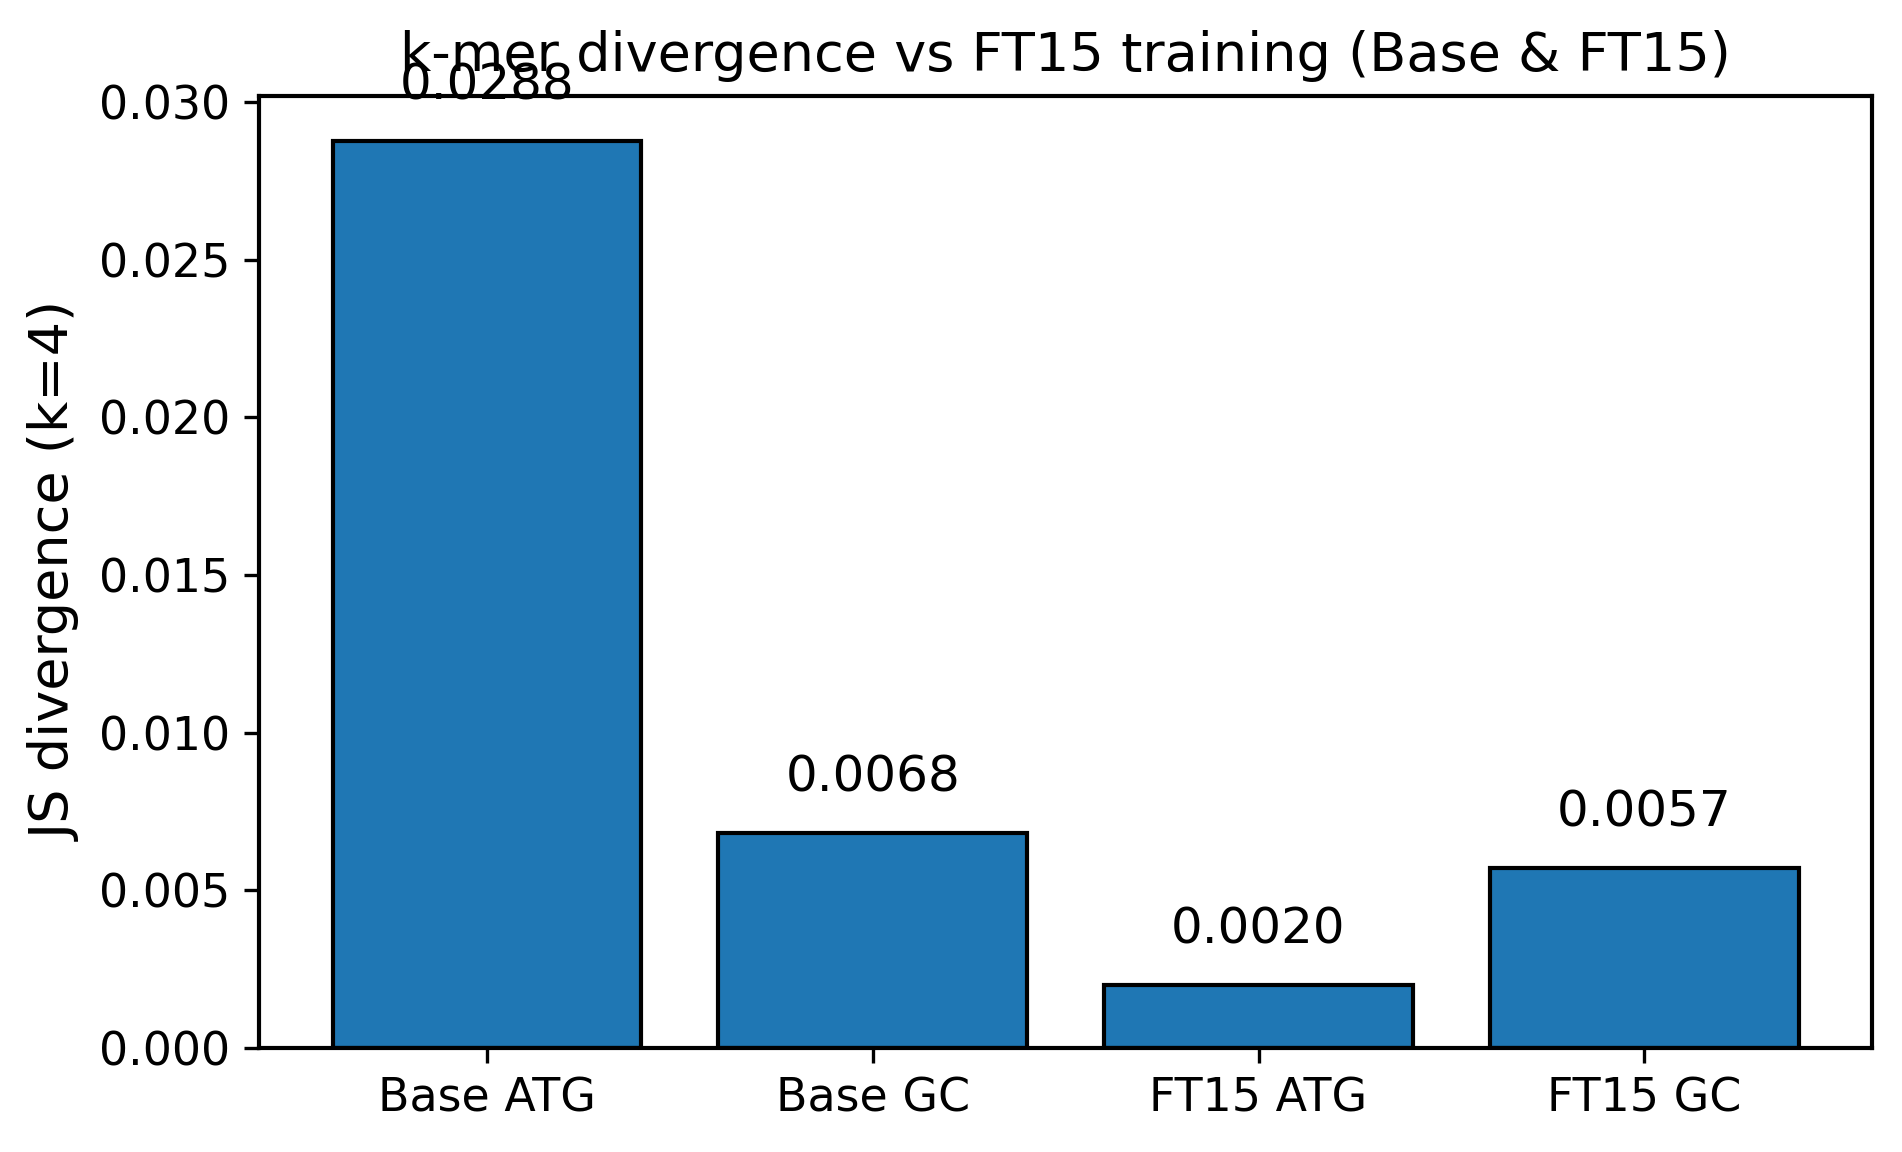

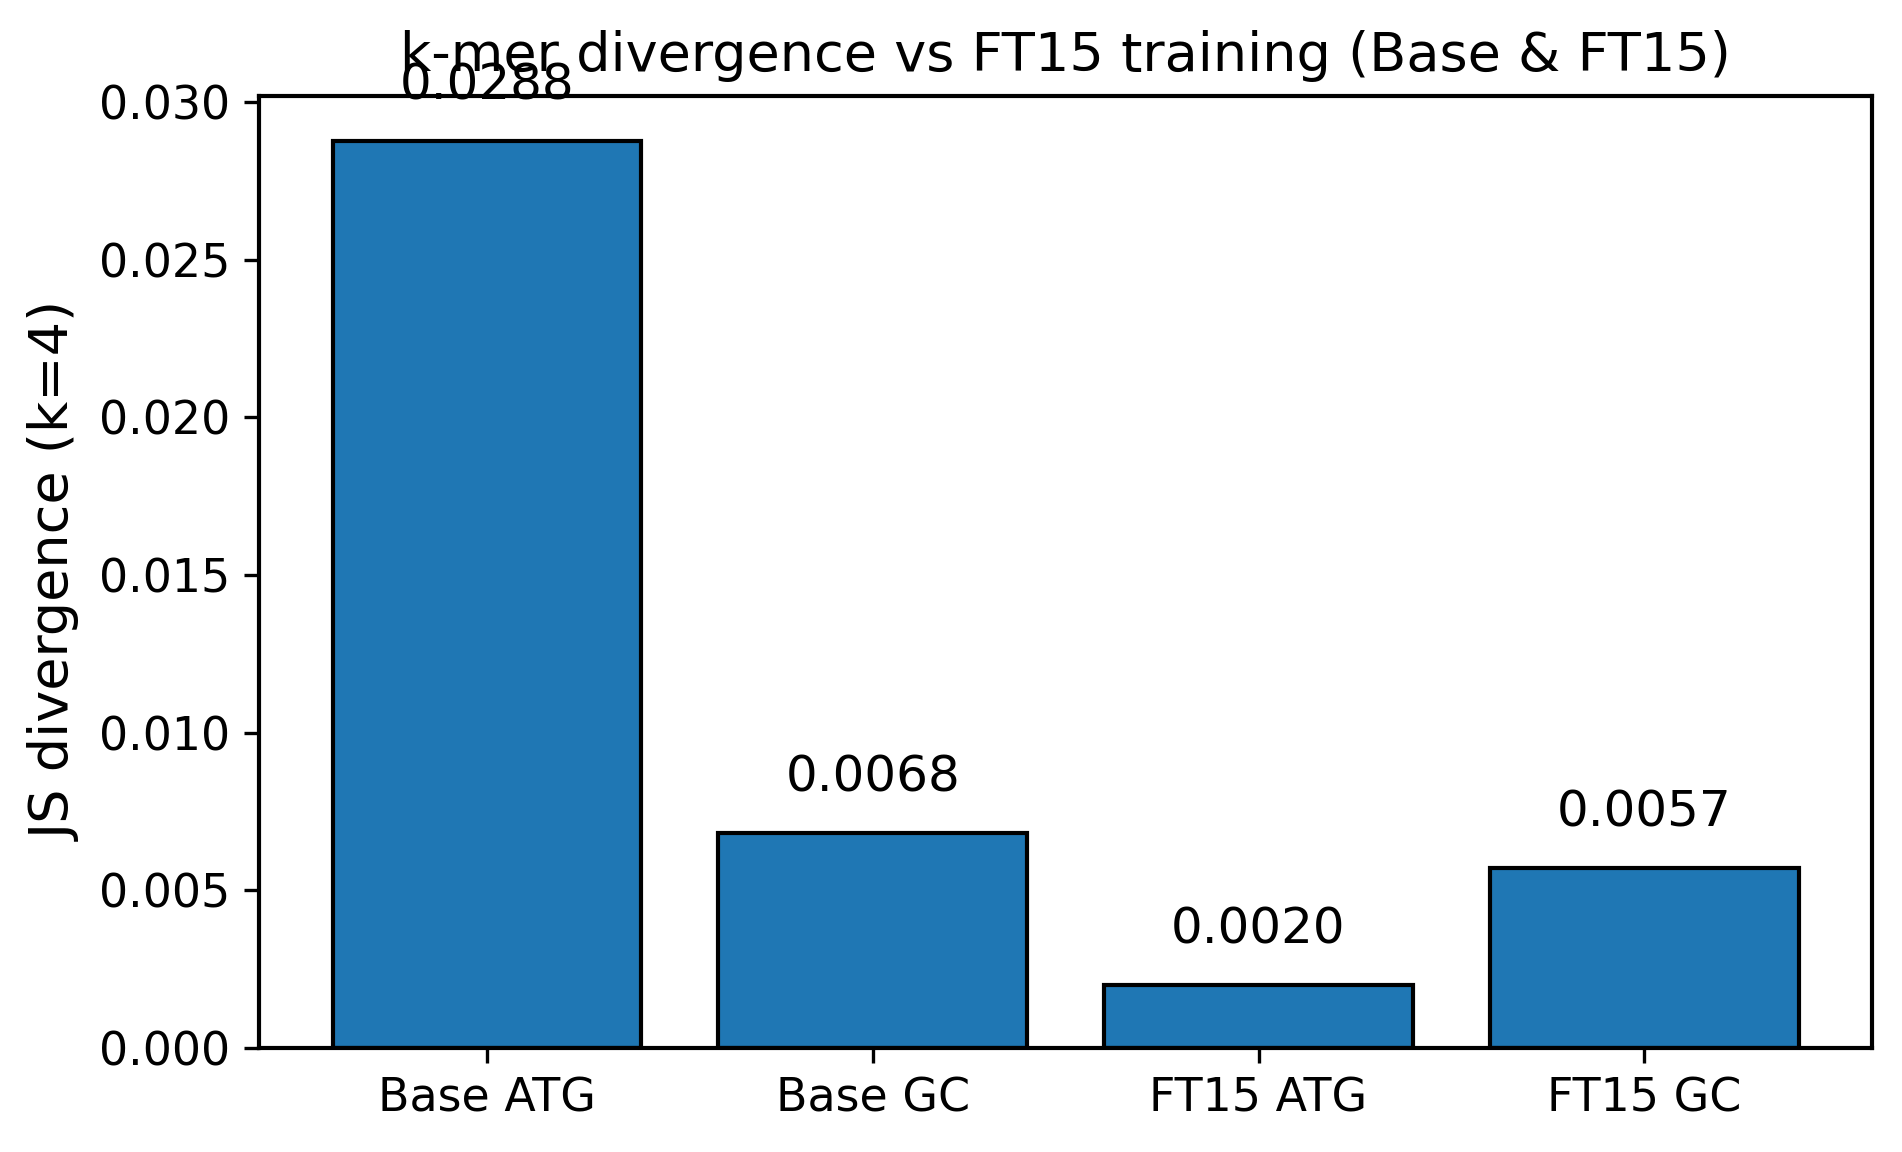

In [ ]:

import matplotlib.pyplot as plt

labels1 = ["Base ATG", "Base GFP", "FT15 ATG", "FT15 GFP"]
sub = df_ft15[(df_ft15["metric"] == "JS") & (df_ft15["k"] == 4) & (df_ft15["target"].isin(labels1))].copy()
sub["label"] = pd.Categorical(sub["target"], categories=labels1, ordered=True)
sub = sub.sort_values("label")

fig, ax = plt.subplots(figsize=(6.5, 4))
x = range(len(labels1))
y = sub["value"].values
bars = ax.bar(x, y, edgecolor="black")
ax.set_xticks(list(x))
ax.set_xticklabels(labels1, rotation=0)
ax.set_ylabel("JS divergence (k=4)")
ax.set_title("k-mer divergence vs FT15 training (Base & FT15)")
for rect, v in zip(bars, y):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.001, f"{v:.4f}", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(OUTDIR / "fig_4_9_ft15group_vs_train15_js_k4.pdf", bbox_inches="tight")
fig


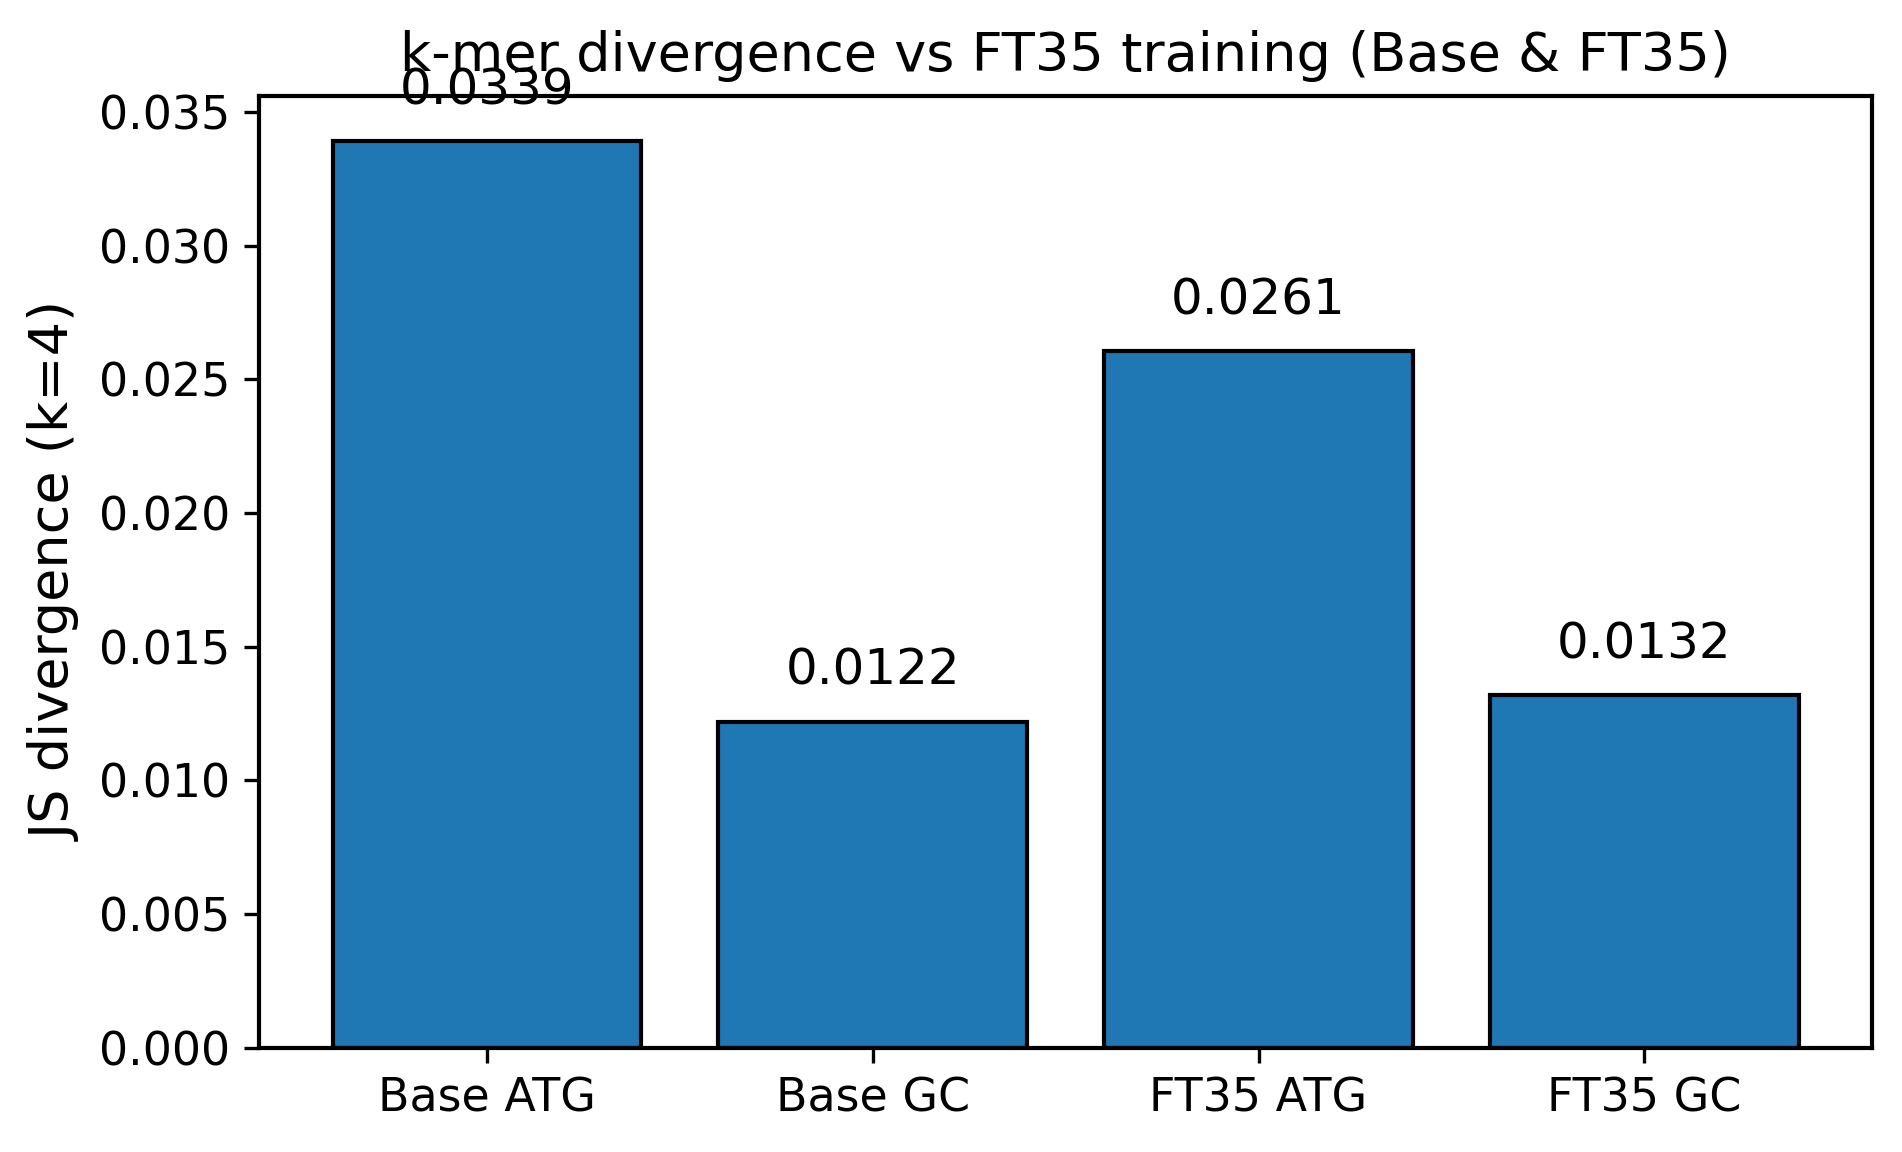

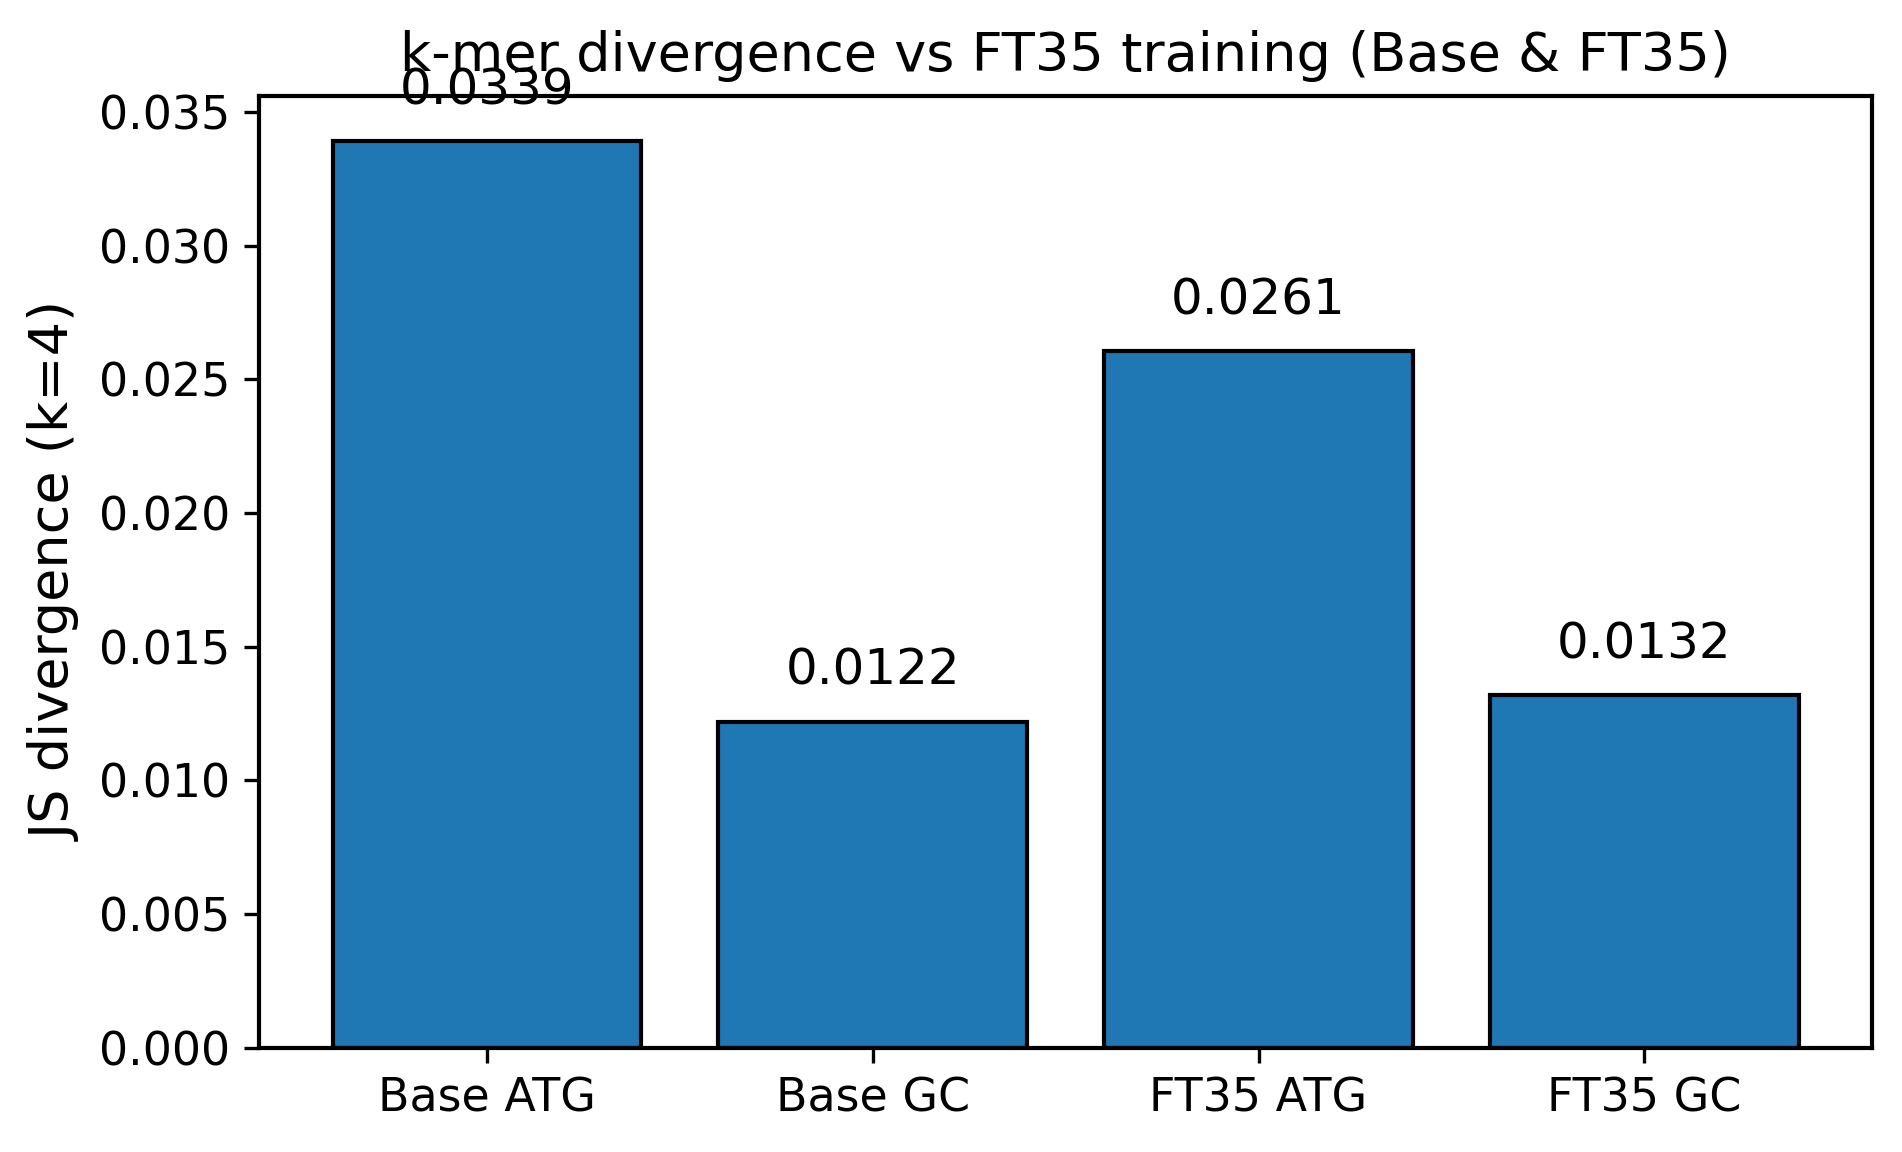

In [ ]:

labels2 = ["Base ATG", "Base GFP", "FT35 ATG", "FT35 GFP"]
sub = df_ft35[(df_ft35["metric"] == "JS") & (df_ft35["k"] == 4) & (df_ft35["target"].isin(labels2))].copy()
sub["label"] = pd.Categorical(sub["target"], categories=labels2, ordered=True)
sub = sub.sort_values("label")

fig, ax = plt.subplots(figsize=(6.5, 4))
x = range(len(labels2))
y = sub["value"].values
bars = ax.bar(x, y, edgecolor="black")
ax.set_xticks(list(x))
ax.set_xticklabels(labels2, rotation=0)
ax.set_ylabel("JS divergence (k=4)")
ax.set_title("k-mer divergence vs FT35 training (Base & FT35)")
for rect, v in zip(bars, y):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.001, f"{v:.4f}", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(OUTDIR / "fig_4_9_ft35group_vs_train35_js_k4.pdf", bbox_inches="tight")
fig


In [ ]:

df_all = pd.concat([df_ft15, df_ft35], ignore_index=True)
OUTDIR = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/analysis/kmer_divergence")
df_all.to_csv(OUTDIR / "kmer_divergence_all.csv", index=False)
df_all.head(50)


,target,train,k,metric,value
0,Base ATG,FT15,3,JS,0.014500
1,Base ATG,FT15,3,KL,0.055806
2,Base ATG,FT15,4,JS,0.028752
3,Base ATG,FT15,4,KL,0.109166
4,Base GC,FT15,3,JS,0.002032
5,Base GC,FT15,3,KL,0.008135
6,Base GC,FT15,4,JS,0.006828
7,Base GC,FT15,4,KL,0.027115
8,FT15 ATG,FT15,3,JS,0.000712
9,FT15 ATG,FT15,3,KL,0.003094


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Fallback OUTDIR if not already defined earlier in the notebook
if "OUTDIR" not in globals():
    OUTDIR = Path("./kmer_plots")
    OUTDIR.mkdir(parents=True, exist_ok=True)

def set_style():
    import matplotlib as mpl
    mpl.rcParams.update({
        "pdf.fonttype": 42, "ps.fonttype": 42,
        "font.size": 12, "axes.labelsize": 13, "axes.titlesize": 13,
        "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
        "figure.dpi": 300, "axes.linewidth": 1.0,
    })
set_style()

def _bars_on_ax(ax, df, labels, *, metric="JS", k=4, ylim_pad=0.20, fmt="{:.4f}"):
    sub = df[(df["metric"] == metric) & (df["k"] == k) & (df["target"].isin(labels))].copy()
    sub["label"] = pd.Categorical(sub["target"], categories=labels, ordered=True)
    sub = sub.sort_values("label")

    x = range(len(labels))
    y = sub["value"].values
    bars = ax.bar(x, y, edgecolor="black")

    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=0)
    ax.set_ylabel(f"{metric} divergence (k={k})")

    # numeric labels with small offset
    for rect, v in zip(bars, y):
        ax.annotate(fmt.format(v), xy=(rect.get_x() + rect.get_width()/2, v),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", clip_on=False)

    # return max height so caller can synchronize y-lims across panels
    ymax = float(y.max()) if len(y) else 0.0
    return ymax

def two_panel_metric(df_left, labels_left, title_left,
                     df_right, labels_right, title_right,
                     *, metric="JS", k=4, outpath=None, figsize=(10, 4), ylim_pad=0.20):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axL, axR = axes

    ymaxL = _bars_on_ax(axL, df_left, labels_left, metric=metric, k=k, ylim_pad=ylim_pad)
    ymaxR = _bars_on_ax(axR, df_right, labels_right, metric=metric, k=k, ylim_pad=ylim_pad)

    axL.set_title(title_left)
    axR.set_title(title_right)

    # synchronize y across panels and add headroom so labels aren't clipped
    ymax = max(ymaxL, ymaxR) if max(ymaxL, ymaxR) > 0 else 1.0
    top = ymax * (1.0 + ylim_pad)
    axL.set_ylim(0, top)
    axR.set_ylim(0, top)
    axL.margins(y=0.02); axR.margins(y=0.02)

    fig.tight_layout()
    if outpath is not None:
        fig.savefig(outpath, bbox_inches="tight")
    fig
    return fig, axes


In [25]:
OUTDIR = Path("/cs/student/projects1/aibh/2024/acunning/Projects/figure_creations/figures") 

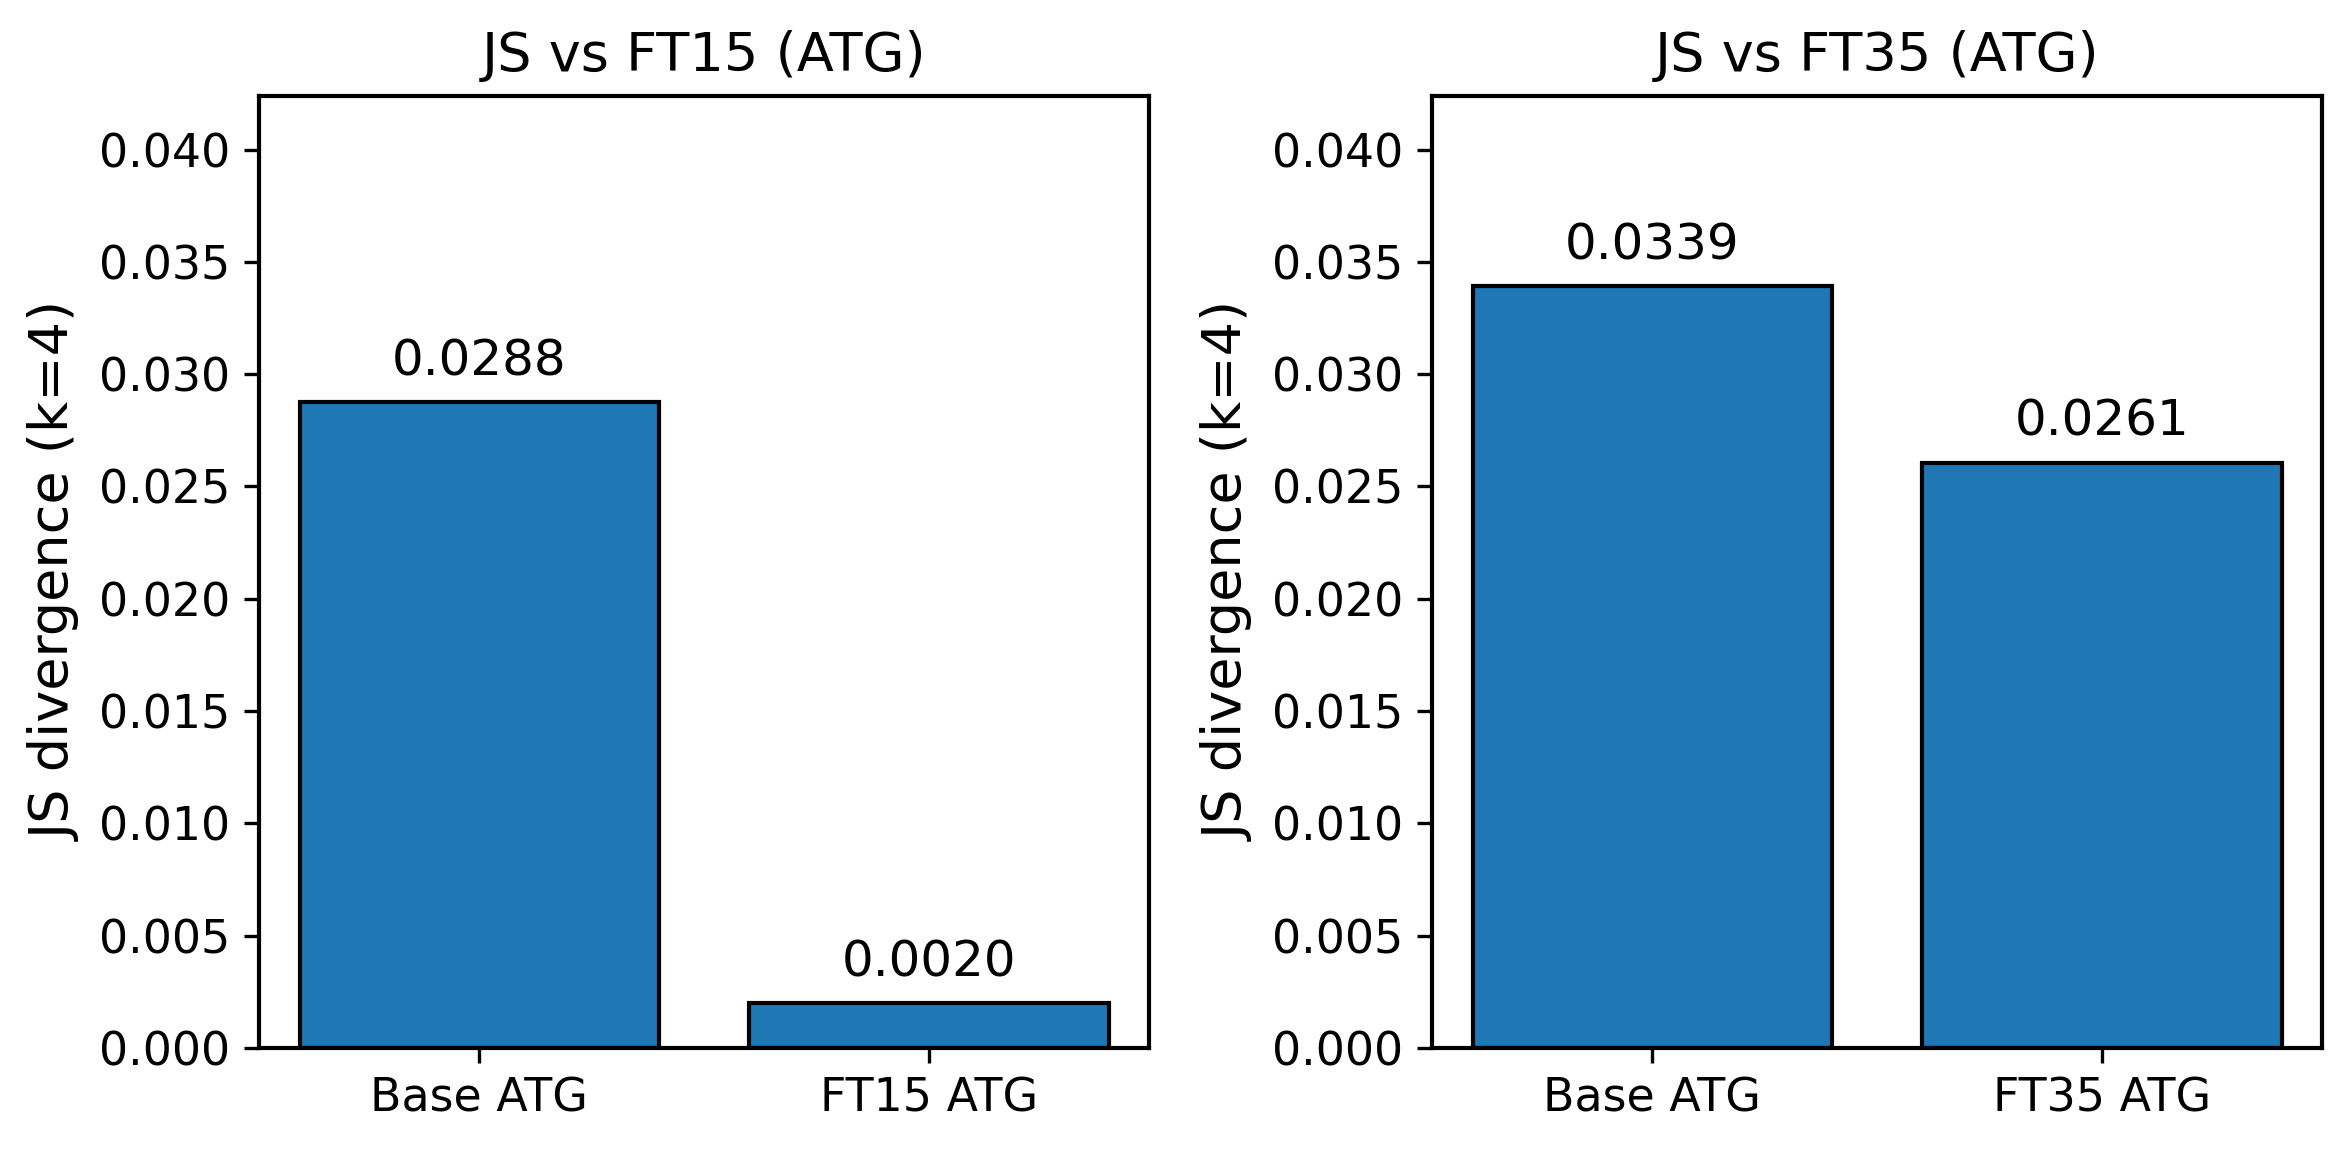

In [26]:
labels_left  = ["Base ATG", "FT15 ATG"]   # vs FT15 training
labels_right = ["Base ATG", "FT35 ATG"]   # vs FT35 training

fig_js, axes_js = two_panel_metric(
    df_left=df_ft15,   labels_left=labels_left,  title_left="JS vs FT15 (ATG)",
    df_right=df_ft35,  labels_right=labels_right, title_right="JS vs FT35 (ATG)",
    metric="JS", k=4, outpath=OUTDIR / "JS_side_by_side_k4.pdf",
    figsize=(8, 4), ylim_pad=0.25  # increase if labels still clip
)


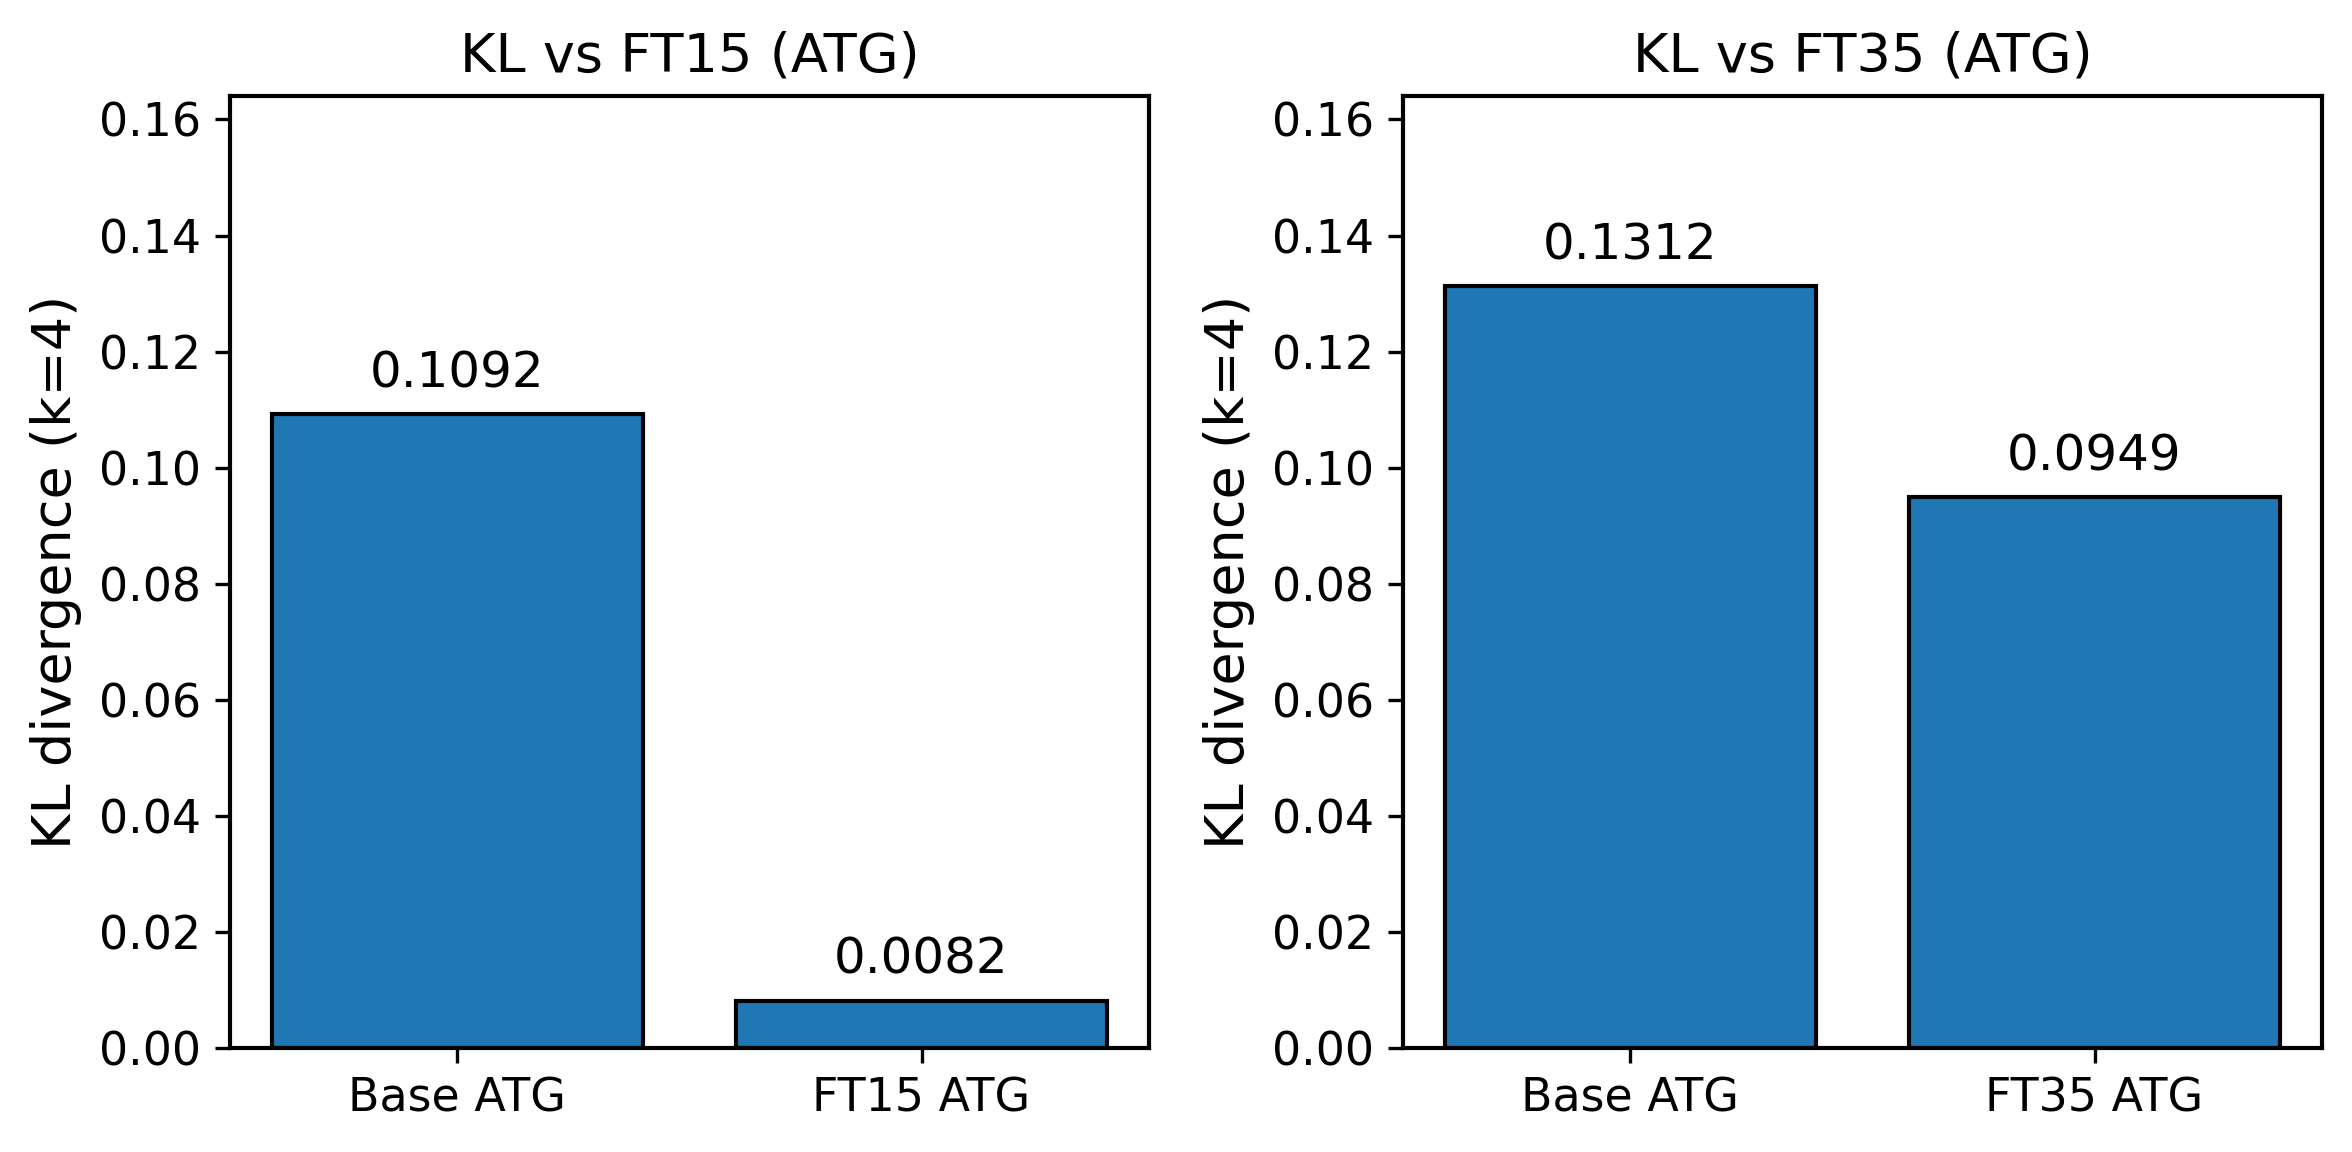

In [27]:
fig_kl, axes_kl = two_panel_metric(
    df_left=df_ft15,   labels_left=["Base ATG", "FT15 ATG"],  title_left="KL vs FT15 (ATG)",
    df_right=df_ft35,  labels_right=["Base ATG", "FT35 ATG"], title_right="KL vs FT35 (ATG)",
    metric="KL", k=4, outpath=OUTDIR / "KL_side_by_side_k4.pdf",
    figsize=(8, 4), ylim_pad=0.25
)
